Connected to base (Python 3.12.7)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load the dataset
penguins = pd.read_csv("palmer_penguins.csv")
penguins = penguins[['bill_length_mm', 'flipper_length_mm']].dropna()

# Normalize the features
scaler = StandardScaler()
X = scaler.fit_transform(penguins)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load and preview the dataset
penguins = pd.read_csv("palmer_penguins.csv")
penguins = penguins[['bill_length_mm', 'flipper_length_mm']].dropna()

penguins.head()

# Summary statistics
penguins.describe()

scaler = StandardScaler()
X = scaler.fit_transform(penguins)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load and preview the dataset
penguins = pd.read_csv("palmer_penguins.csv")
penguins = penguins[['bill_length_mm', 'flipper_length_mm']].dropna()

print(penguins.head())

# Summary statistics
print(penguins.describe())

scaler = StandardScaler()
X = scaler.fit_transform(penguins)

   bill_length_mm  flipper_length_mm
0            39.1                181
1            39.5                186
2            40.3                195
3            36.7                193
4            39.3                190
       bill_length_mm  flipper_length_mm
count      333.000000         333.000000
mean        43.992793         200.966967
std          5.468668          14.015765
min         32.100000         172.000000
25%         39.500000         190.000000
50%         44.500000         197.000000
75%         48.600000         213.000000
max         59.600000         231.000000


In [ ]:
def initialize_centroids(X, k):
    np.random.seed(42)
    return X[np.random.choice(X.shape[0], k, replace=False)]

def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

def compute_wcss(X, labels, centroids):
    return sum(np.sum((X[labels == i] - centroids[i])**2) for i in range(k))

def kmeans(X, k, max_iter=100):
    centroids = initialize_centroids(X, k)
    for _ in range(max_iter):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    wcss = compute_wcss(X, labels, centroids)
    return labels, centroids, wcss

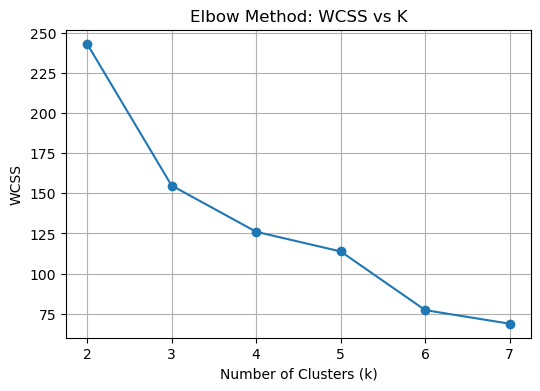

In [ ]:
wcss_list = []
k_range = range(2, 8)

for k in k_range:
    _, _, wcss = kmeans(X, k)
    wcss_list.append(wcss)

plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss_list, marker='o')
plt.title("Elbow Method: WCSS vs K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

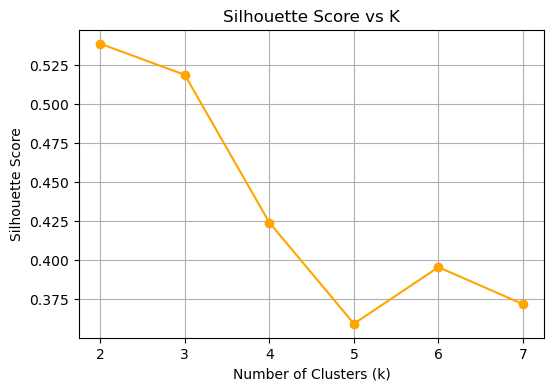

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in k_range:
    labels, _, _ = kmeans(X, k)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6, 4))
plt.plot(k_range, silhouette_scores, marker='o', color='orange')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

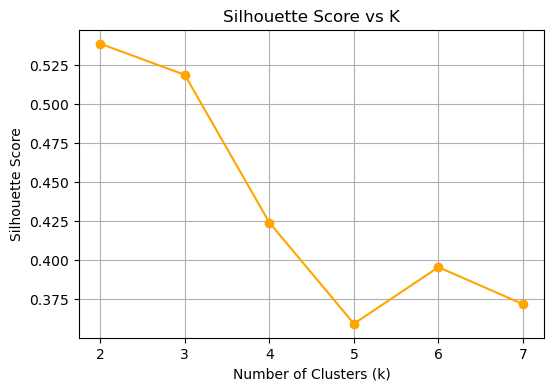

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in k_range:
    labels, _, _ = kmeans(X, k)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6, 4))
plt.plot(k_range, silhouette_scores, marker='o', color='orange')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

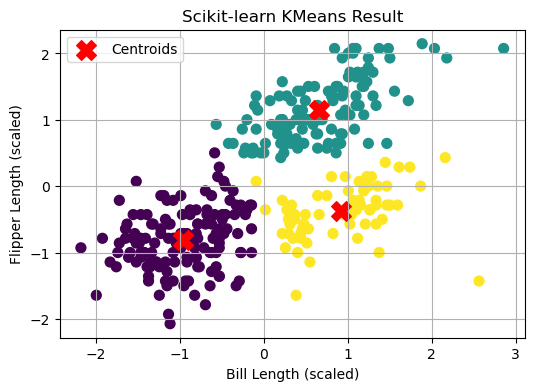

In [ ]:
from sklearn.cluster import KMeans

k = 3  # Example: set based on elbow/silhouette
model = KMeans(n_clusters=k, random_state=42)
model.fit(X)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=model.labels_, cmap='viridis', s=50)
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("Scikit-learn KMeans Result")
plt.xlabel("Bill Length (scaled)")
plt.ylabel("Flipper Length (scaled)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 100
x1 = np.random.uniform(-3, 3, n)
x2 = np.random.uniform(-3, 3, n)
boundary = np.sin(4 * x1) + x1
y = (x2 > boundary).astype(int)

X_train = np.column_stack((x1, x2))
y_train = y

```{r}
# gen data -----
set.seed(42)
n <- 100
x1 <- runif(n, -3, 3)
x2 <- runif(n, -3, 3)
x <- cbind(x1, x2)

# define a wiggly boundary
boundary <- sin(4*x1) + x1
y <- ifelse(x2 > boundary, 1, 0) |> as.factor()
dat <- data.frame(x1 = x1, x2 = x2, y = y)

SyntaxError: invalid syntax (<ipython-input-9-a685e912aa3c>, line 15)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 100
x1 = np.random.uniform(-3, 3, n)
x2 = np.random.uniform(-3, 3, n)
boundary = np.sin(4 * x1) + x1
y = (x2 > boundary).astype(int)

X_train = np.column_stack((x1, x2))
y_train = y

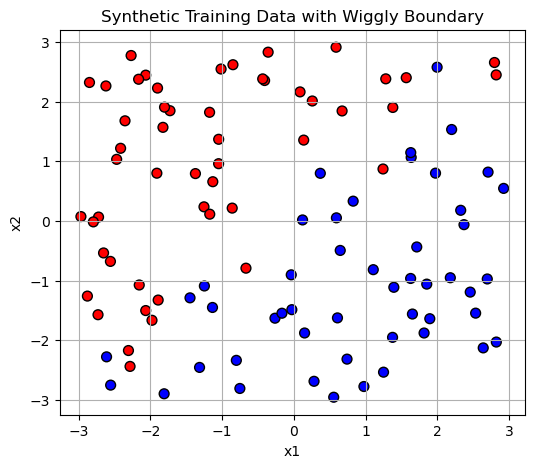

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(x1, x2, c=y, cmap="bwr", edgecolor="k", s=50)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Synthetic Training Data with Wiggly Boundary")
plt.grid(True)
plt.show()

In [ ]:
np.random.seed(7)
x1_test = np.random.uniform(-3, 3, n)
x2_test = np.random.uniform(-3, 3, n)
boundary_test = np.sin(4 * x1_test) + x1_test
y_test = (x2_test > boundary_test).astype(int)

X_test = np.column_stack((x1_test, x2_test))

In [ ]:
from collections import Counter

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2, axis=1))

def knn_predict(X_train, y_train, X_test, k):
    predictions = []
    for test_point in X_test:
        distances = euclidean_distance(X_train, test_point)
        k_indices = np.argsort(distances)[:k]
        k_neighbors = y_train[k_indices]
        top_vote = Counter(k_neighbors).most_common(1)[0][0]
        predictions.append(top_vote)
    return np.array(predictions)

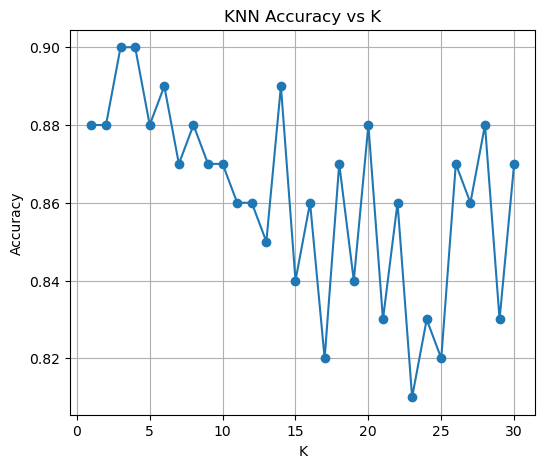

In [ ]:
from sklearn.metrics import accuracy_score

accuracies = []
k_values = range(1, 31)

for k in k_values:
    y_pred = knn_predict(X_train, y_train, X_test, k)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure(figsize=(6, 5))
plt.plot(k_values, accuracies, marker='o')
plt.title("KNN Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()